In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.interpolate import LSQUnivariateSpline
from scipy.interpolate import CubicSpline

In [2]:
#numerical derivative approximation
#F is the function, h is the interval size, x is the point where the derivative is evaluated
def num_derv (F, h,x):
    return ( ((-11.0*F(x))/6.0 + 3.0*F(h + x) - (3.0*F(2.0*h + x))/2.0 + F(3.0*h + x)/3.0)/h )*(1/F(x))

In [3]:
#Load the GQ data file
Q,GQ = np.loadtxt("GQ.dat",delimiter=",",unpack=True)

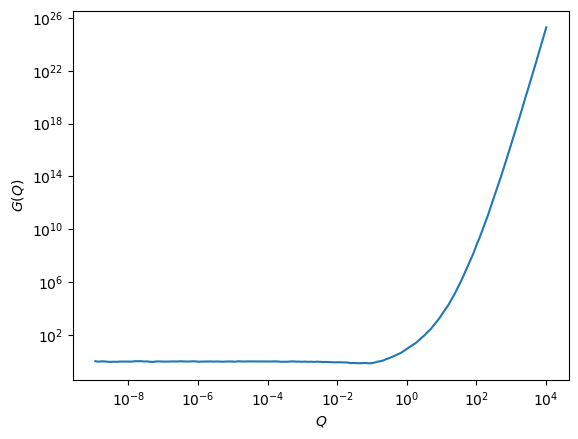

In [4]:
#plot raw data
plt.plot(Q,GQ)
plt.xscale("log",base=10)
plt.yscale("log",base=10)
plt.xlabel("$Q$")
plt.ylabel("$G(Q)$")
plt.show()

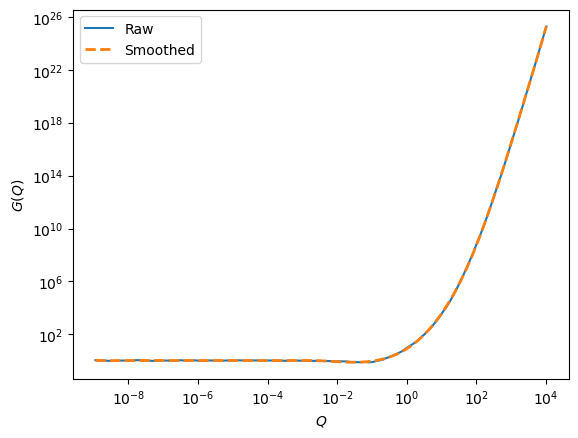

In [5]:
#Smoothing method based on knots
# transform to log–log
x = np.log10(Q)
y = np.log10(GQ)

#Increase the number of knots until the smooth and raw G(Q) roughly match
n_knots = 9

knots = np.quantile(
    x,
    np.linspace(0.05, 0.95, n_knots)
)

spl = LSQUnivariateSpline(x, y, knots, k=3)

y_smooth = spl(x)
Gsmooth = 10**y_smooth

plt.plot(Q, GQ, label="Raw")
plt.plot(Q, Gsmooth, label="Smoothed", linewidth=2,linestyle="--")
plt.xscale("log",base=10)
plt.yscale("log",base=10)
plt.xlabel("$Q$")
plt.ylabel("$G(Q)$")
plt.legend()
# plt.ylim(0.5,2)
plt.show()

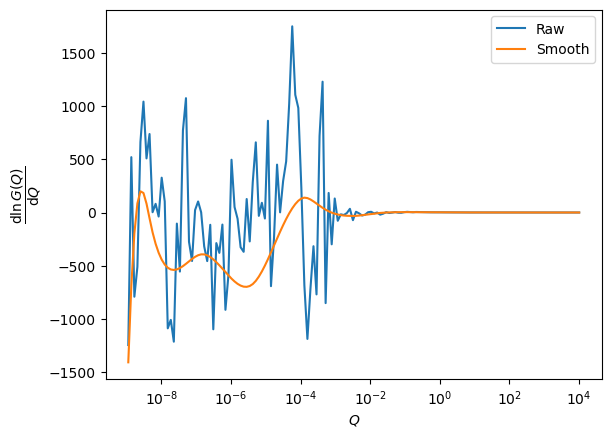

In [6]:
#Plot raw derivative
logGasQ = CubicSpline(np.log10(Q),np.log10(GQ))
def G_Q (Q):
    return 10**logGasQ(np.log10(Q))
plt.plot(Q,num_derv(G_Q,1e-4,Q),label="Raw")
logGasQ = CubicSpline(np.log10(Q),np.log10(Gsmooth))
def G_Q (Q):
    return 10**logGasQ(np.log10(Q))
plt.plot(Q,num_derv(G_Q,1e-4,Q),label="Smooth")
plt.xscale("log",base=10)
plt.legend()
plt.xlabel("$Q$")
plt.ylabel(r"$\dfrac{\text{d}\ln G(Q)}{\text{d}Q}$")
# plt.yscale("log",base=10)
plt.show()

In [7]:
#Run this cell once you are happy with the results of smoothing
#This cell writes the smoothed data which can then be interpolated and used to calculate the semi-analytical power spectrum
with open("GQ_smooth.dat", "w") as fl:
    for i,j in zip(Q,Gsmooth):
            fl.write(str(i)+","+str(j)+"\n")